## Libraries

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
import os
from types import SimpleNamespace
from itertools import combinations
from scipy.spatial.distance import pdist, cdist, squareform
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr
from joblib import Parallel, delayed

sys.path.append("/path/to/mCNV_FISH/pipeline")
from workspace import Workspace
from env import BASE_PATH

In [20]:
sns.set_context("poster")
sns.set_style('white')

## Load workspace

In [ ]:
args = SimpleNamespace(
    run_type = 'bandpass', 
    data_id = 'data_id', 
    seg_model = 'cellpose_modelD',
    run_notes = 'run_notes',
    fov_file = 'fovs.txt')
ws = Workspace(args)

fovs = ws.load_fovs()
fovs_to_process = fovs.flatten()

probes = pd.read_csv(f"Pipeline_utility_files/mCNV-FISH_probeinfo_sept2022KMS.csv", sep = ",")
gene_order = probes.sort_values(['Chromosome', 'exon start'])['Gene'].values
gene_order = [g for g in gene_order if g in ws.bits.genes.values]
bit_order = ws.bits.reset_index().set_index('genes').loc[gene_order].bits_list.values

## Plot no. of spots per nucleus

In [4]:
fdr = 0.05

passed = pd.read_csv(ws.get_segmentation_qc_dir() / f'passed_filtered_fdr_{fdr}.csv', index_col = 0)
passed = passed[passed["passed_filtered"] == True].reset_index(drop=True)

num_spots = []
coords = []

for bit in ws.bits.index:
    for fov in fovs_to_process: 

        if fov == "xxx":
            continue

        cells_passed = passed[(passed['fov'] == int(fov)) & (passed['passed_filtered'])]["label"]

        coords_ = ws.get_stitched_peaks(fov, bit, fdr)
        coords_["spot_id"] = coords_.groupby(["fov", "cell_id"]).cumcount()
        coords.append(coords_)

        num_spots_per_cell = coords_['cell_id'].value_counts().reindex(cells_passed).fillna(0).astype(int)
        num_spots_per_cell = pd.DataFrame({'n': num_spots_per_cell, "bit": bit, "fov": fov})
        num_spots_per_cell['cell_id'] = num_spots_per_cell.index
        num_spots_per_cell.index = [f'FOV{fov}_X{c}' for c in num_spots_per_cell.index]
        num_spots.append(num_spots_per_cell)

coords = pd.concat(coords).reset_index(drop=True)
coords['bit_cell_spot'] = [f'{c.bit}_{c.cell_id}_{c.spot_id}' for _, c in coords.iterrows()]

num_spots = pd.concat(num_spots)

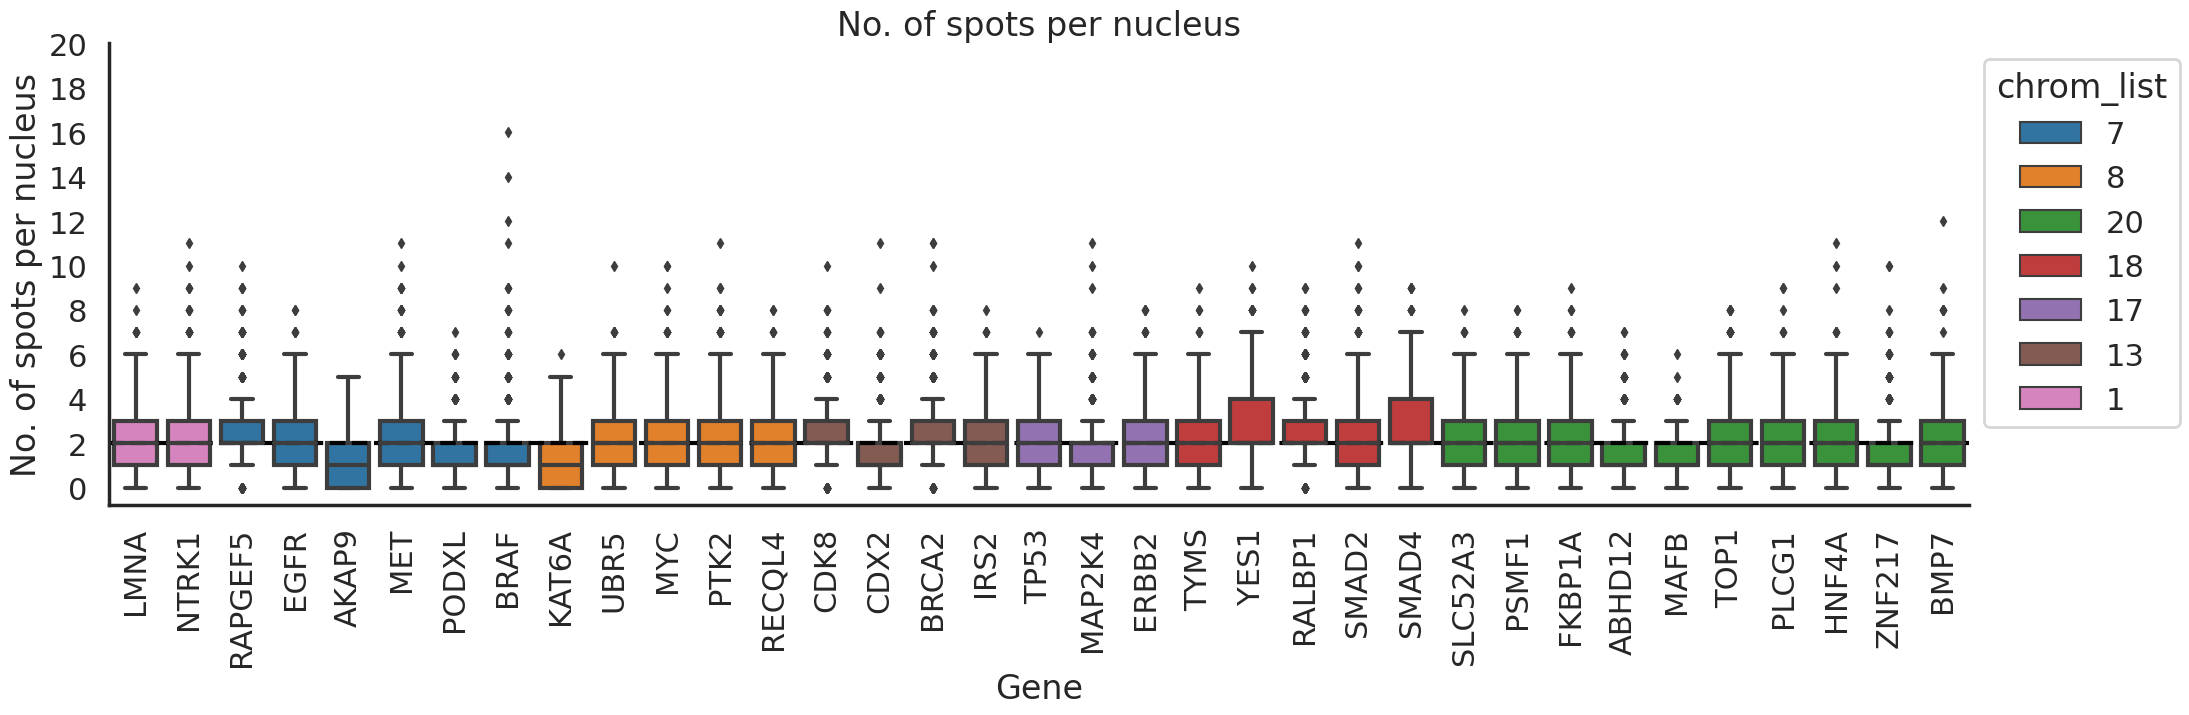

In [5]:
to_plot = pd.merge(num_spots, ws.bits.reset_index(), left_on = 'bit', right_on = 'bits_list')

fig, ax = plt.subplots(figsize = (24, 6))

g = sns.boxplot(data = to_plot, x = 'genes', y = 'n', ax = ax, 
    order = gene_order, hue = 'chrom_list', dodge = False, 
    hue_order = [7, 8, 20, 18, 17, 13, 1]
    )
g.set_xticklabels(g.get_xticklabels(), rotation = 90)
g.axhline(2, linestyle = 'dashed', linewidth = 3, color = 'black')

g.set_xlabel('Gene')
g.set_ylabel('No. of spots per nucleus')
g.set_yticks(range(0, 21, 2))

g.set_title(f"No. of spots per nucleus")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()

Text(0.5, 1.0, 'No. of spots per nucleus')

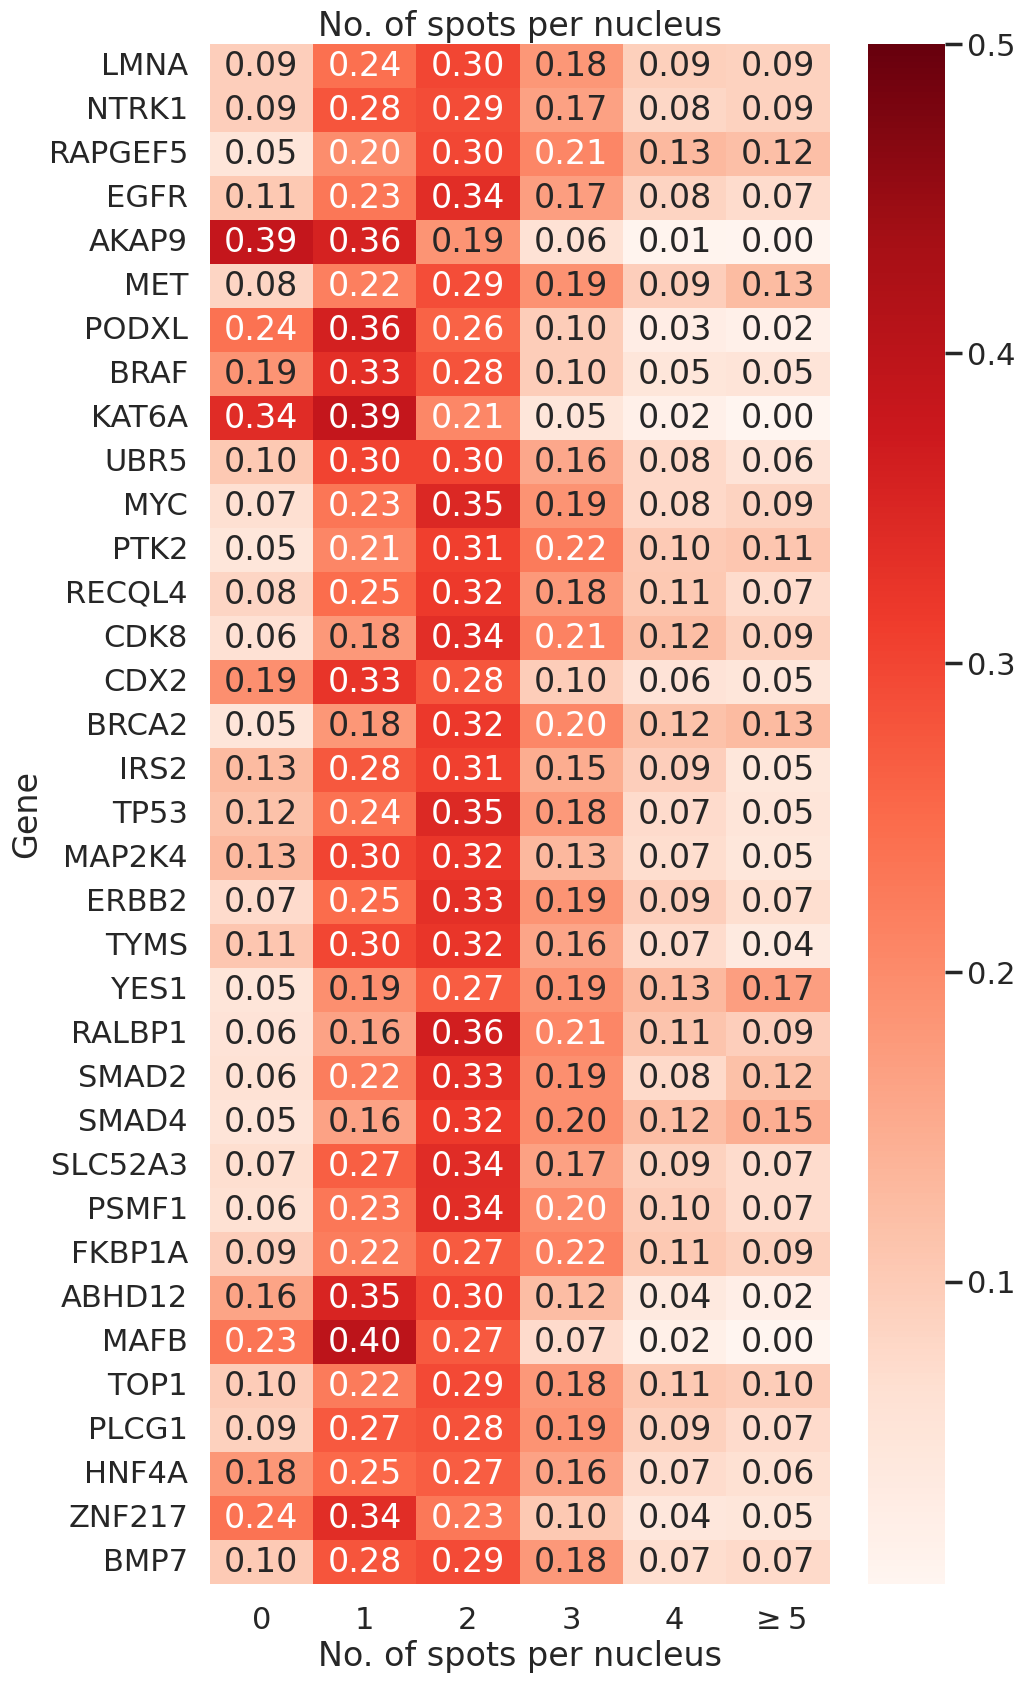

In [6]:
to_plot = num_spots.groupby(['bit', 'n'])['cell_id'].count().reset_index()
to_plot.loc[to_plot['n'] > 4, 'n'] = r'$\geq5$'
to_plot = to_plot.groupby(['bit', 'n'])['cell_id'].sum().reset_index()

to_plot = pd.merge(to_plot, ws.bits.reset_index(), left_on = 'bit', right_on = 'bits_list')
to_plot = to_plot.set_index(['genes', 'n'])['cell_id'].unstack().fillna(0).astype(int)
to_plot = to_plot.loc[gene_order]
to_plot = to_plot.divide(to_plot.sum(axis = 1), axis = 0)

fig, ax = plt.subplots(figsize = (10, 20))

g = sns.heatmap(to_plot, ax = ax, annot = True, fmt = '.2f', cmap = sns.color_palette("Reds", as_cmap=True), vmax = 0.5)

g.set_xlabel('No. of spots per nucleus')
g.set_ylabel('Gene')
g.set_title(f"No. of spots per nucleus")

## Generate matched spots and check for signal bleeding

In [57]:
def run_match_spots(fov_in, coords):

    coords_subset = coords[coords["fov"] == fov_in]
    matched_spots = []
    
    for bit_a, bit_b in combinations(ws.bits.index, 2):
        for (fov, cell_id), cell_spots in coords_subset.groupby(['fov', 'cell_id']):
            
            spots_a = cell_spots.loc[cell_spots['bit'] == bit_a]
            spots_b = cell_spots.loc[cell_spots['bit'] == bit_b]
            
            cd = cdist(spots_a[['r_micron', 'c_micron', 'z_micron']], spots_b[['r_micron', 'c_micron', 'z_micron']])
            cd = pd.DataFrame(cd)
            cd.index = spots_a['bit_cell_spot'].values
            cd.columns = spots_b['bit_cell_spot'].values
            
            cd_ = cd.copy()

            while (cd_.shape[0] > 0) & (cd_.shape[1] > 0):
                ind = np.unravel_index(np.argmin(cd_.values, axis=None), cd_.shape)
            
                v = cd_.iloc[ind[0], ind[1]]
                spot_aa = cd_.index[ind[0]]
                spot_bb = cd_.columns[ind[1]]
            
                cd_ = cd_.drop(spot_aa).drop(spot_bb, axis = 1)
            
                matched_spots.append((fov, cell_id, bit_a, bit_b, spot_aa, spot_bb, v))
    
    matched_spots = pd.DataFrame(matched_spots)
    matched_spots.columns = ['fov', 'cell_id', 'bit_a', 'bit_b', 'spot_a', 'spot_b', 'distance']
    matched_spots.to_csv(f"{BASE_PATH}/{dataset}_F{fov_in}_matched_spots.csv", sep=",")

In [69]:
Parallel(n_jobs = 4)(
                delayed(run_match_spots)(fov, coords)
                    for fov in fovs_to_process if fov!='xxx')

Matching spots for FOV 080


[None, None]

Matching spots for FOV 081


In [7]:
fovs_valid = [elem for elem in fovs_to_process if elem not in ['xxx']]

matched_spots = pd.DataFrame(columns=['fov', 'cell_id', 'bit_a', 'bit_b', 'spot_a', 'spot_b', 'distance'])

for fov in fovs_valid:
    tmp = pd.read_csv(f"{BASE_PATH}/{dataset}_F{fov}_matched_spots.csv", index_col=0)
    matched_spots = pd.concat([matched_spots, tmp])
    
matched_spots

,fov,cell_id,bit_a,bit_b,spot_a,spot_b,distance
0,80,1,0,1,0_1_0,1_1_1,3.118914
1,80,4,0,1,0_4_0,1_4_0,6.445354
2,80,5,0,1,0_5_0,1_5_0,0.928578
3,80,7,0,1,0_7_0,1_7_1,2.692377
4,80,8,0,1,0_8_1,1_8_0,3.810661
...,...,...,...,...,...,...,...
608367,81,1281,33,34,33_1281_0,34_1281_0,5.799407
608368,81,1286,33,34,33_1286_1,34_1286_0,3.069667
608369,81,1319,33,34,33_1319_0,34_1319_0,2.487481
608370,81,1321,33,34,33_1321_1,34_1321_0,2.325754


In [8]:
mean_matched = matched_spots.groupby(['bit_a', 'bit_b'])['distance'].mean()

mean_matched_dd = pd.DataFrame(0, index = bit_order, columns = bit_order)
for bit_a in bit_order:
    for bit_b in bit_order:
        if bit_a == bit_b: continue
        try:
            mmd = mean_matched.loc[(bit_a, bit_b)]
        except KeyError:
            mmd = mean_matched.loc[(bit_b, bit_a)]
        mean_matched_dd.loc[bit_a, bit_b] = mmd
        mean_matched_dd.loc[bit_b, bit_a] = mmd
        
mean_matched_dd

,32,21,4,25,34,29,0,3,2,1,...,18,9,30,17,20,33,22,27,24,5
32,0.000000,1.717009,3.185558,3.248924,3.206764,3.212809,3.109689,3.328202,3.149909,3.149795,...,2.957898,2.979217,2.957130,3.115671,3.040798,2.981151,2.985646,3.044379,2.969454,3.040792
21,1.717009,0.000000,3.274068,3.186291,3.323719,3.160448,3.191493,3.252921,3.300691,3.149725,...,3.046711,3.035906,3.080296,3.181074,3.154377,3.028037,3.047117,2.958333,3.093145,2.861432
4,3.185558,3.274068,0.000000,1.900431,2.117631,2.397844,2.320040,2.453521,3.129967,3.178760,...,3.064473,3.128767,2.638700,3.202823,3.122721,3.041267,3.126951,3.138246,3.087847,3.143152
25,3.248924,3.186291,1.900431,0.000000,2.072048,2.191411,2.299882,2.282462,3.231636,3.195188,...,3.160862,3.032385,2.600671,3.193543,3.208342,2.969152,3.129075,3.048936,3.176725,3.077581
34,3.206764,3.323719,2.117631,2.072048,0.000000,1.913562,2.275784,2.315486,3.535087,3.279611,...,3.112973,3.105753,2.432309,3.365889,3.461296,2.958895,3.058401,3.254346,3.350731,3.226801
29,3.212809,3.160448,2.397844,2.191411,1.913562,0.000000,2.112235,2.122998,3.102482,3.121199,...,3.140995,3.092813,2.744822,3.150734,3.073256,2.974565,3.123062,3.071227,3.124366,3.101168
0,3.109689,3.191493,2.320040,2.299882,2.275784,2.112235,0.000000,2.153127,3.414970,3.281800,...,3.119123,3.078717,2.664226,3.317228,3.328270,3.117311,3.138040,3.224357,3.236999,3.166559
3,3.328202,3.252921,2.453521,2.282462,2.315486,2.122998,2.153127,0.000000,3.581972,3.196464,...,3.244213,3.177818,2.881091,3.411274,3.512360,3.131158,3.307469,3.112678,3.379611,3.106147
2,3.149909,3.300691,3.129967,3.231636,3.535087,3.102482,3.414970,3.581972,0.000000,2.302206,...,3.032336,3.065812,3.018122,3.347452,3.413520,2.945486,3.063684,3.163688,3.112593,3.142864
1,3.149795,3.149725,3.178760,3.195188,3.279611,3.121199,3.281800,3.196464,2.302206,0.000000,...,3.141243,2.997101,3.077621,3.134282,3.283339,2.972094,3.109161,3.102496,3.197181,3.052122


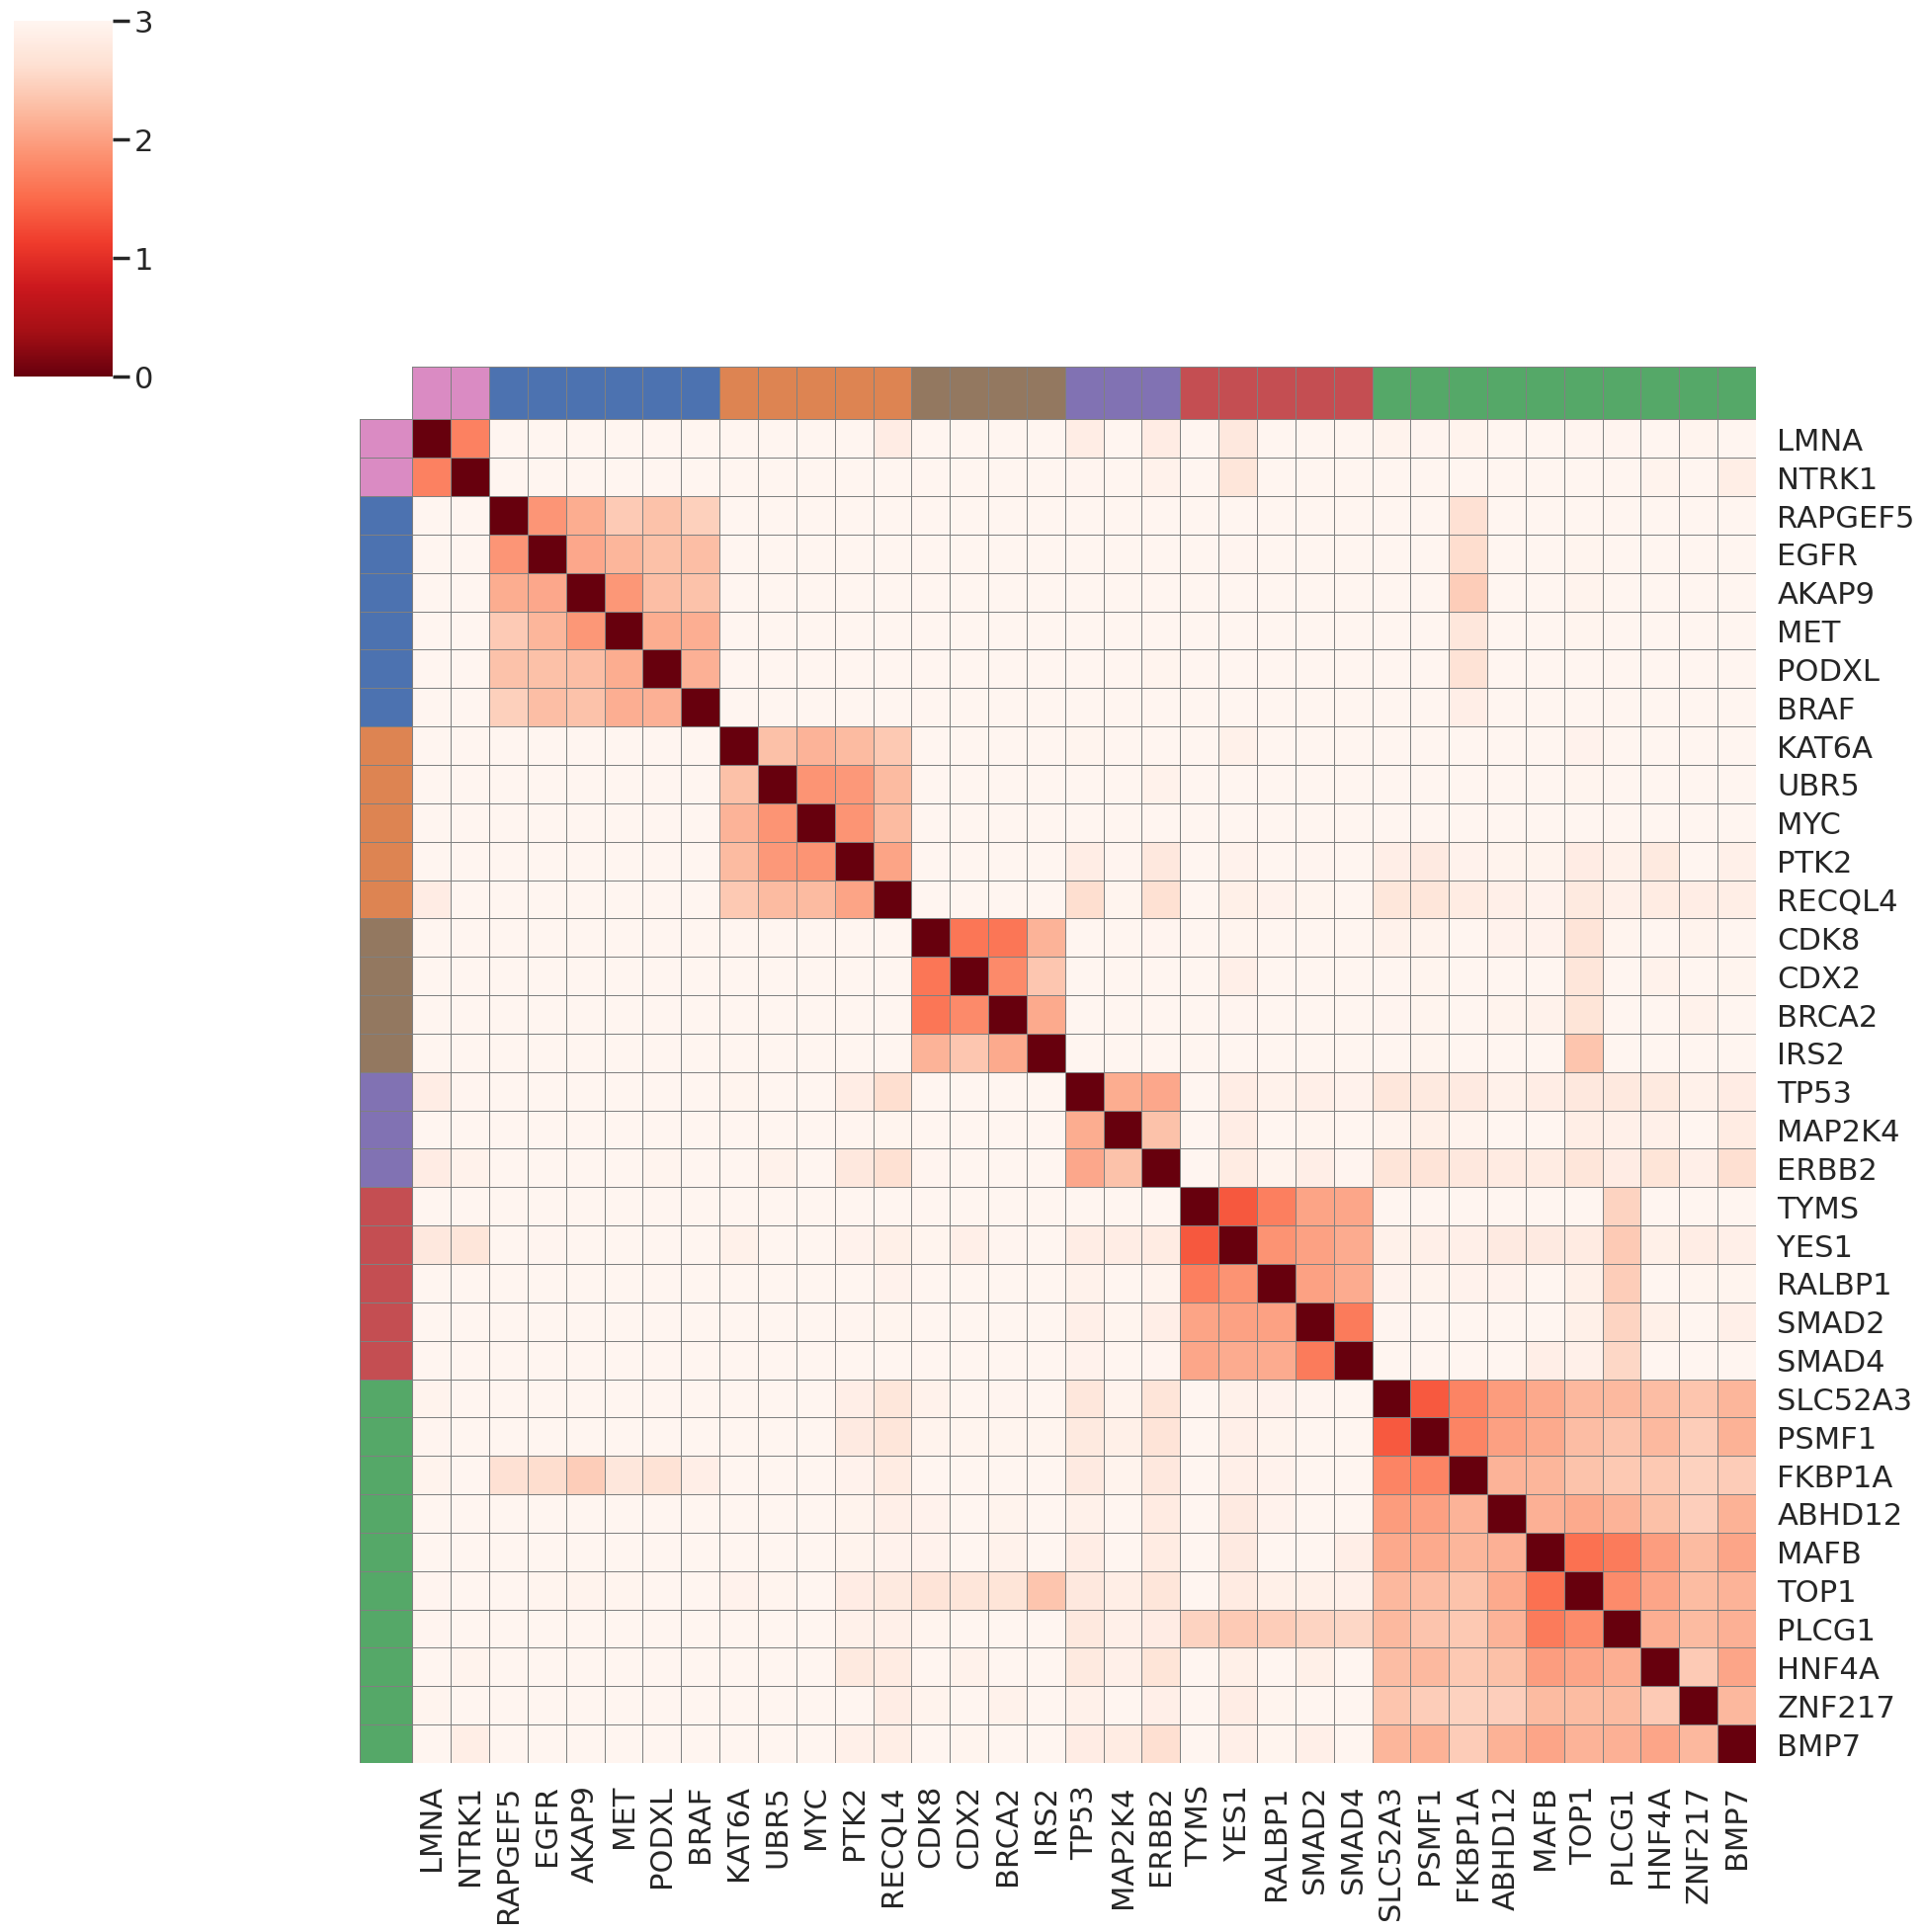

In [9]:
chrom_to_color = dict(zip([7, 8, 20, 18, 17, 13, 1], sns.color_palette("deep")))
chrom_color = [chrom_to_color[c] for c in ws.bits.loc[bit_order, 'chrom_list'].values]

g = sns.clustermap(mean_matched_dd, 
    row_cluster = False, col_cluster = False,
    vmax=3,
    row_colors = chrom_color,
    col_colors = chrom_color, 
    xticklabels = gene_order, 
    yticklabels = gene_order,
    figsize = (20, 20),
    cmap= sns.color_palette("Reds_r",as_cmap=True),
    linewidths=0.5,
    linecolor="grey")
g.ax_heatmap.axes.tick_params(right = False)

In [10]:
probe_dists = []

for chrom, probes_ in probes.merge(ws.bits.reset_index()[['bits_list', 'genes']], 
    left_on = 'Gene', right_on = 'genes', how = 'right').set_index('bits_list').groupby('Chromosome'): 

    probes_['mid'] = (probes_['exon start'] + (probes_['exon stop'] - probes_['exon start'])/2).astype(int)
    
    for bit_a, bit_b in combinations(probes_.index, 2):
        probe_dist = abs(probes_.loc[bit_a, 'mid'] - probes_.loc[bit_b, 'mid'])
        probe_dists.append((f'chr{int(chrom)}', bit_a, bit_b, probe_dist, mean_matched_dd.loc[bit_a, bit_b]))

probe_dists = pd.DataFrame(probe_dists)
probe_dists.columns = ['chrom', 'bit_a', 'bit_b', 'probe_dist', 'hyb_dist']

r, pval = pearsonr(probe_dists['probe_dist'], probe_dists['hyb_dist'])

Text(0.5, 1.0, 'r = 0.586, p = 1.26e-09')

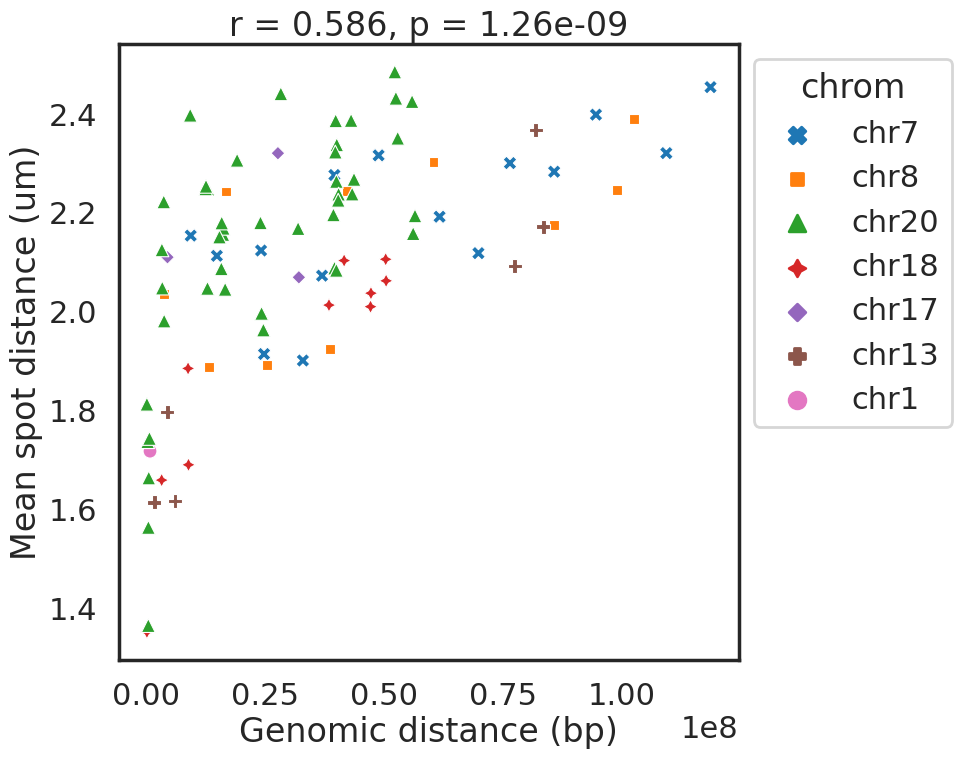

In [11]:
fig, ax = plt.subplots(figsize = (8, 8))

g = sns.scatterplot(data = probe_dists, x = 'probe_dist', y = 'hyb_dist', ax = ax,
    hue = 'chrom', style = 'chrom', s = 100, 
    hue_order = ['chr7', 'chr8', 'chr20', 'chr18', 'chr17', 'chr13', 'chr1'])

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

g.set_xlabel('Genomic distance (bp)')
g.set_ylabel('Mean spot distance (um)')
g.set_title(f'r = {r:.3f}, p = {pval:.2e}')

In [12]:
for channel in ["Cy5", "Cy3"]:
    layout = pd.read_csv(f"{BASE_PATH}/hyb_design_{channel}.csv", header=None)
    print(layout)

       0       1        2       3        4     5      6
0  PODXL   KAT6A  RAPGEF5    TYMS   RALBP1   NaN    NaN
1  SMAD4    TP53     CDK8   BRCA2  SLC52A3  MAFB    NaN
2  PLCG1  ZNF217      MYC  RECQL4   FKBP1A  LMNA  AKAP9
       0      1      2       3      4      5
0   UBR5   BRAF   BMP7  MAP2K4  PSMF1    NaN
1  ERBB2  SMAD2   YES1  ABHD12   CDX2  NTRK1
2   PTK2   EGFR  HNF4A     MET   IRS2   TOP1


In [13]:
cat_dd = []
relationships_master = {}

for channel in ["Cy5", "Cy3"]:
    
    layout = pd.read_csv(f"{BASE_PATH}/hyb_design_{channel}.csv", header=None)

    rows = []

    for _, row in layout.iterrows():
        genes = row.dropna().tolist()
    
        if len(genes) > 0:
            rows.append(genes)
    
    gene_ordering = [gene for row in rows for gene in row]
    
    gene_to_order = {gene: i for i, gene in enumerate(gene_ordering)}
    
    gene_pos = {}
    
    for r, row in enumerate(rows):
        for c, gene in enumerate(row):
            gene_pos[gene] = (r, c)
    
    relationships = {}
    
    for gene in gene_ordering:
    
        idx = gene_to_order[gene]
    
        next_gene = (
            gene_ordering[idx + 1]
            if idx < len(gene_ordering) - 1
            else None
        )
    
        prev_gene = (
            gene_ordering[idx - 1]
            if idx > 0
            else None
        )
    
        r, c = gene_pos[gene]
    
        partner_gene_down = None
    
        for rr in range(r + 1, len(rows)):
    
            if c < len(rows[rr]):
                partner_gene_down = rows[rr][c]
                break
    
        partner_gene_up = None
    
        for rr in range(r - 1, -1, -1):
        
            if c < len(rows[rr]):
                partner_gene_up = rows[rr][c]
                break
    
        relationships[gene] = {
            "next_hyb_right": next_gene,
            "prev_hyb_left": prev_gene,
            "next_hyb_down": partner_gene_down,
            "prev_hyb_up": partner_gene_up
        }

    relationships_master[channel] = relationships
    
    bits_reset = ws.bits.reset_index()
    gene_to_bits = (bits_reset.set_index("genes")["bits_list"].to_dict())
    hyb_lookup = (bits_reset.groupby("hyb_list")["bits_list"].apply(list).to_dict())
    chr_lookup = (bits_reset.groupby("chrom_list")["bits_list"].apply(list).to_dict())
    
    
    def make_distance_df(source_bit, target_bits, category):
    
        if len(target_bits) == 0:
            return pd.DataFrame(columns=["distances", "category", "bits_list"])
    
        distances = (mean_matched_dd.loc[source_bit, target_bits].values)
    
        return pd.DataFrame({
            "distances": distances,
            "category": category,
            "bits_list": source_bit})
    
    
    cat_dd_tmp = []
    
    for bits_list_, bit in ws.bits.iterrows():
    
        gene = bit.genes
    
        if gene not in relationships:
            continue
    
        rel = relationships[gene]
    
        next_bits = []
    
        if rel["next_hyb_right"] is not None:
            if rel["next_hyb_right"] in gene_to_bits:
    
                next_bits.append(gene_to_bits[rel["next_hyb_right"]])
    
        cat_dd_tmp.append(make_distance_df(bits_list_, next_bits, "next_hyb_right"))
    
        prev_bits = []
    
        if rel["prev_hyb_left"] is not None:
            if rel["prev_hyb_left"] in gene_to_bits:
    
                prev_bits.append(gene_to_bits[rel["prev_hyb_left"]])
    
        cat_dd_tmp.append(make_distance_df(bits_list_, prev_bits, "prev_hyb_left"))
    
        partner_down_bits = []
    
        if rel["next_hyb_down"] is not None:
            if rel["next_hyb_down"] in gene_to_bits:
    
                partner_down_bits.append(gene_to_bits[rel["next_hyb_down"]])
    
        cat_dd_tmp.append(make_distance_df(bits_list_, partner_down_bits, "next_hyb_down"))
    
        partner_up_bits = []
    
        if rel["prev_hyb_up"] is not None:
            if rel["prev_hyb_up"] in gene_to_bits:
    
                partner_up_bits.append(gene_to_bits[rel["prev_hyb_up"]])
    
        cat_dd_tmp.append(make_distance_df(bits_list_, partner_up_bits, "prev_hyb_up"))
    
        same_hyb_bits = [b for b in hyb_lookup.get(bit.hyb_list, []) if b != bits_list_]
        cat_dd_tmp.append(make_distance_df(bits_list_, same_hyb_bits, "partner_channel"))
    
        same_chr_bits = [b for b in chr_lookup.get(bit.chrom_list, []) if b != bits_list_]
        cat_dd_tmp.append(make_distance_df(bits_list_, same_chr_bits, "same_chr"))
    
    
    cat_dd_tmp = pd.concat(cat_dd_tmp, ignore_index=True)
    
    cat_dd_tmp = pd.merge(
        cat_dd_tmp,
        bits_reset,
        on="bits_list",
        how="left"
    )

    cat_dd.append(cat_dd_tmp)

cat_dd = pd.concat(cat_dd)
cat_dd = cat_dd.sort_values(by="bits_list").reset_index(drop=True)

cat_dd['label'] = cat_dd['hyb_list'].astype(str) + "%"+ cat_dd['type_list'].astype(str) + "\n"+ cat_dd['genes'].astype(str) + "\n"+ "Bit " + cat_dd["bits_list"].astype(str)

status_mapping = {
    'next_hyb_right': 'Next hyb (right)',
    'next_hyb_down' : 'Next hyb (down)',
    'prev_hyb_left': 'Prev hyb (left)',
    'prev_hyb_up': 'Prev hyb (up)',
    'partner_channel': 'Partner channel',
    'same_chr': 'Same chr'
}

cat_dd['category'] = cat_dd['category'].map(status_mapping)

cat_dd

,distances,category,bits_list,type_list,hyb_list,chrom_list,genes,label
0,3.414970,Next hyb (right),0,Cy5,0,7,PODXL,0%Cy5\nPODXL\nBit 0
1,3.232100,Next hyb (down),0,Cy5,0,7,PODXL,0%Cy5\nPODXL\nBit 0
2,3.281800,Partner channel,0,Cy5,0,7,PODXL,0%Cy5\nPODXL\nBit 0
3,2.153127,Same chr,0,Cy5,0,7,PODXL,0%Cy5\nPODXL\nBit 0
4,2.320040,Same chr,0,Cy5,0,7,PODXL,0%Cy5\nPODXL\nBit 0
...,...,...,...,...,...,...,...,...
319,2.072048,Same chr,34,Cy5,17,7,AKAP9,17%Cy5\nAKAP9\nBit 34
320,2.117631,Same chr,34,Cy5,17,7,AKAP9,17%Cy5\nAKAP9\nBit 34
321,2.315486,Same chr,34,Cy5,17,7,AKAP9,17%Cy5\nAKAP9\nBit 34
322,3.206764,Prev hyb (left),34,Cy5,17,7,AKAP9,17%Cy5\nAKAP9\nBit 34


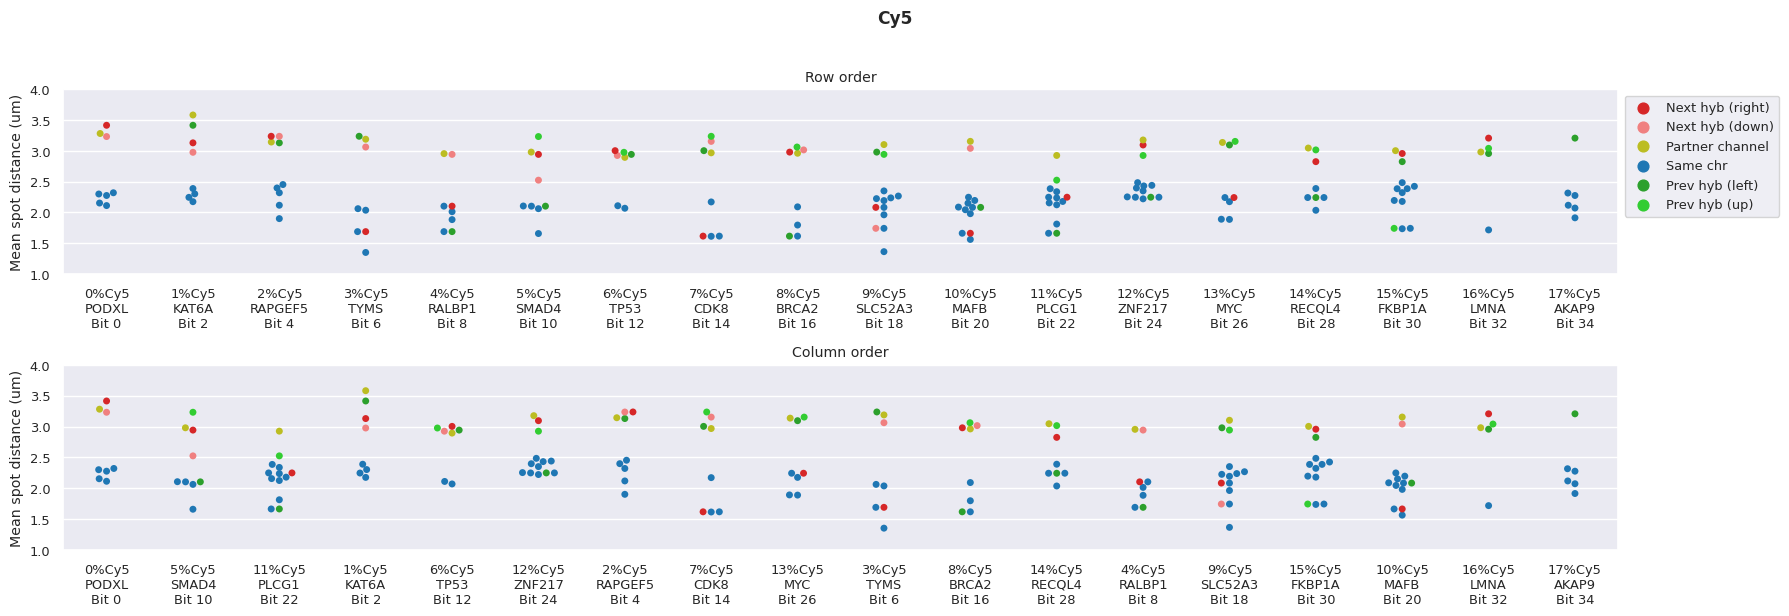

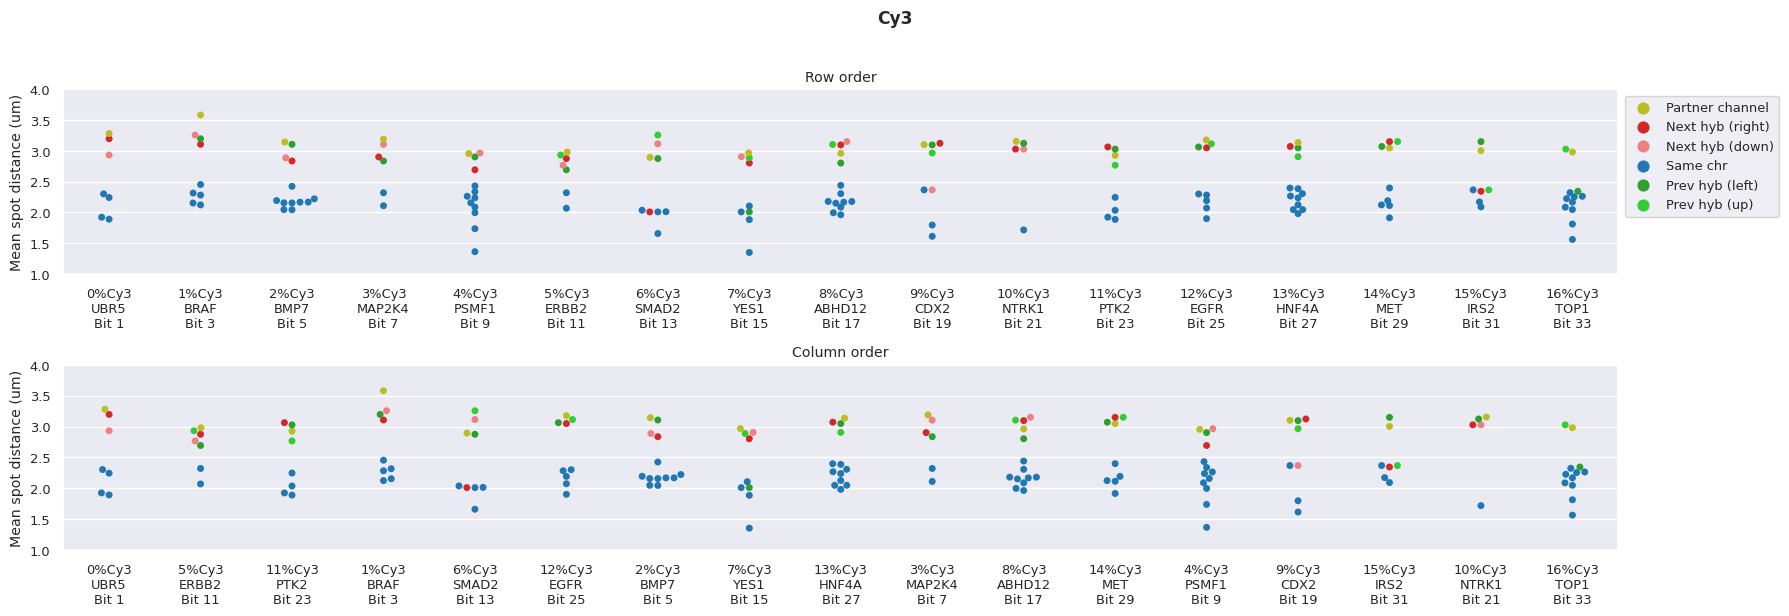

In [14]:
ordering = {}

for channel in ["Cy5", "Cy3"]:
    
    layout = pd.read_csv(f"{BASE_PATH}/hyb_design_{channel}.csv", header=None)
    cat_dd_labels = dict(zip(cat_dd["genes"], cat_dd["label"]))
    
    row_order = [gene for _, row in layout.iterrows() for gene in row.dropna()]
    row_order = [cat_dd_labels[gene] for gene in row_order]
    col_order = [gene for col in layout.columns for gene in layout[col].dropna()]
    col_order = [cat_dd_labels[gene] for gene in col_order]

    cat_dd_plot = cat_dd[cat_dd["type_list"] == channel]

    palette = ["tab:red", "lightcoral", "tab:olive", "tab:blue", "tab:green", "limegreen"]
    categories = ["Next hyb (right)", "Next hyb (down)", "Partner channel", "Same chr", "Prev hyb (left)", "Prev hyb (up)"]
    color_map = dict(zip(categories, palette))
    
    sns.set(font_scale=0.85)

    fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharey=True)
    
    sns.swarmplot(
        data=cat_dd_plot,
        x="label",
        y="distances",
        hue="category",
        order=row_order,
        palette=color_map,
        size=5,
        ax=axes[0]
    )
    
    axes[0].set_title(f"Row order")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Mean spot distance (um)")
    axes[0].set_ylim(1, 4)

    sns.swarmplot(
        data=cat_dd_plot,
        x="label",
        y="distances",
        hue="category",
        order=col_order,
        palette=color_map,
        size=5,
        ax=axes[1]
    )
    
    axes[1].set_title(f"Column order")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Mean spot distance (um)")
    axes[1].set_ylim(1, 4)
    
    axes[1].legend_.remove()
    axes[0].legend(loc = "upper left", bbox_to_anchor=(1, 1))
    
    fig.suptitle(f"{channel}", y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Remove signal bleeding spots

In [15]:
hyb_pairs = {}

for channel in ["Cy5", "Cy3"]:
    relationships = relationships_master[channel]

    for key, val in relationships.items():
        partners = []
        if val["next_hyb_right"] is not None:
            partners.append(gene_to_bits[val["next_hyb_right"]])

        if val["next_hyb_down"] is not None:
            partners.append(gene_to_bits[val["next_hyb_down"]])
        hyb_pairs[gene_to_bits[key]] = partners

hyb_pairs = {k:v for k,v in hyb_pairs.items() if v != []}

In [16]:
matched_spots_filtered = []

for ind, row in matched_spots.iterrows():
    bit_a = row["bit_a"]
    bit_b = row["bit_b"]
    
    if bit_a == 33:
        continue
    elif bit_b in hyb_pairs[bit_a]:
        matched_spots_filtered.append(row)
        
matched_spots_filtered = pd.DataFrame(matched_spots_filtered).reset_index(drop=True)

In [17]:
pixels = 3
dist = pixels * 0.12755

to_drop = []

for ind, row in matched_spots_filtered.iterrows():
    if row["distance"] < dist:
        to_drop.append(row)
        
to_drop = pd.DataFrame(to_drop)

coords.set_index(["bit", "fov", "bit_cell_spot"], inplace=True)
to_drop_coords = coords.loc[list(zip(to_drop["bit_b"], to_drop["fov"].astype(str).str.zfill(3), to_drop["spot_b"]))]
to_drop_coords.reset_index(inplace=True)
to_drop_coords = to_drop_coords.drop_duplicates()
coords.reset_index(inplace=True)

coords_no_sigbleach = coords.merge(to_drop_coords, how='outer', indicator=True).query('_merge == "left_only"').drop('_merge', axis=1)
coords_no_sigbleach.to_csv(f"{BASE_PATH}/{dataset}_coords_noSigBleeding.csv",sep=",")
coords_no_sigbleach

,bit,fov,bit_cell_spot,z,r,c,intensities,volume,intden,cell_id,r_micron,c_micron,z_micron,spot_id
0,0,080,0_73_0,4,728,759,0.542864,6.0,2.982594,73,92.85640,96.81045,1.08,0
1,0,080,0_143_0,5,1013,706,0.858512,30.0,18.230158,143,129.20815,90.05030,1.35,0
2,0,080,0_33_0,6,416,147,1.259705,88.0,63.854202,33,53.06080,18.74985,1.62,0
3,0,080,0_325_0,6,1753,1314,0.786783,29.0,16.651291,325,223.59515,167.60070,1.62,0
4,0,080,0_59_0,7,605,362,0.806991,27.0,15.548869,59,77.16775,46.17310,1.89,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72172,34,081,34_1194_0,44,177,1133,0.765104,11.0,7.703327,1194,22.57635,144.51415,11.88,0
72173,34,081,34_142_4,44,475,1074,0.903323,24.0,17.552208,142,60.58625,136.98870,11.88,4
72174,34,081,34_566_2,46,1421,1050,0.665614,5.0,3.199948,566,181.24855,133.92750,12.42,2
72175,34,081,34_1286_0,46,1521,67,0.665246,3.0,1.965801,1286,194.00355,8.54585,12.42,0


## No. of spots removed per gene due to signal bleeding

In [18]:
coords_no_sigbleach["dropped"] = False
to_drop_coords["dropped"] = True

to_plot = pd.concat([coords_no_sigbleach, to_drop_coords])

summary = to_plot.groupby('bit')['dropped'].agg(dropped_count='sum', total_count='size').reset_index()
summary = pd.merge(summary, ws.bits.reset_index(), left_on = "bit", right_on = 'bits_list')
summary['proportion'] = summary['dropped_count'] / summary['total_count']
summary['label'] = summary["hyb_list"].astype(str) + "%" + summary["type_list"] + "\n" + summary["genes"]

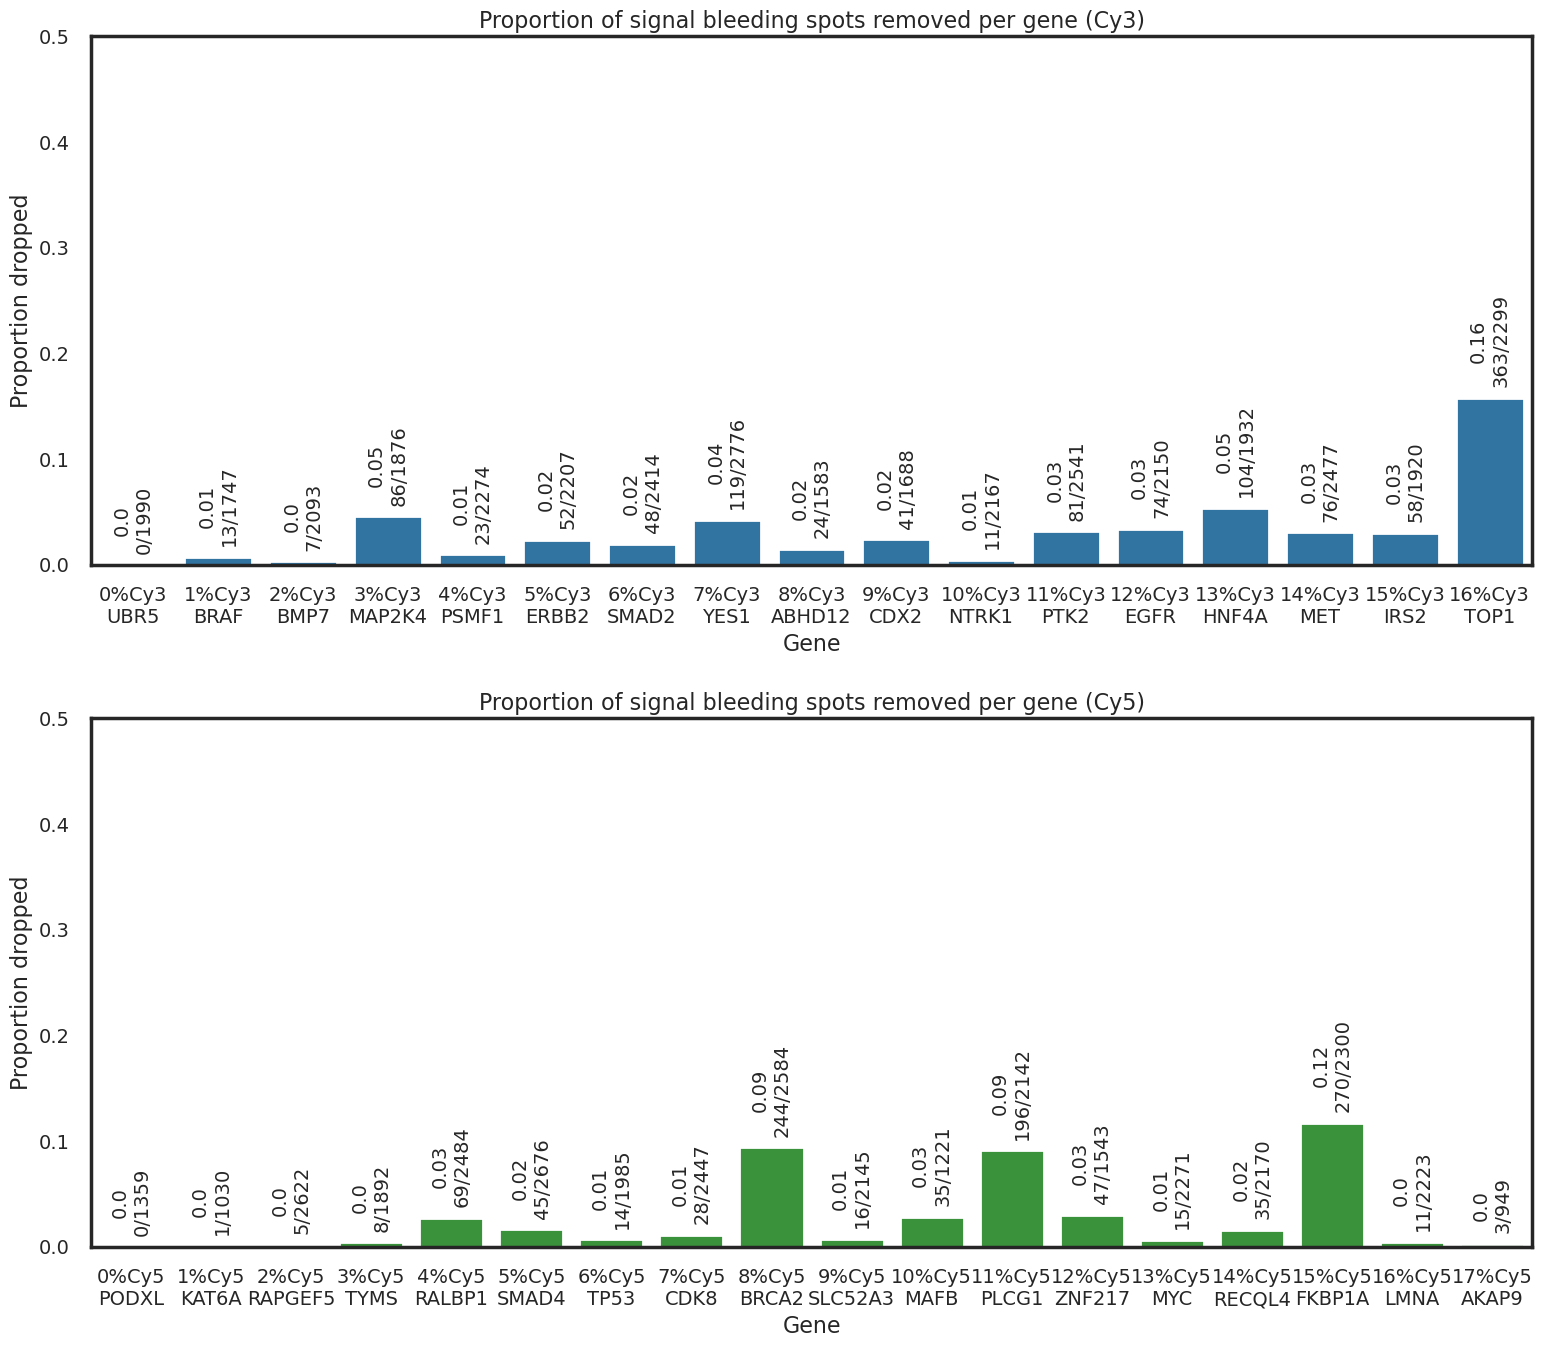

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharey=True)

configs = [
    ("Cy3", "tab:blue", axes[0]),
    ("Cy5", "tab:green", axes[1])
]

for type_name, color, ax in configs:

    df = summary[summary["type_list"] == type_name].reset_index(drop=True)

    g = sns.barplot(data=df, x="label", y="proportion", color=color, ax=ax)

    for index, row in df.iterrows():
        ax.text(index, row["proportion"] + 0.01,
            f"{round(row['proportion'], 2)}\n{row['dropped_count']}/{row['total_count']}",
            ha="center", va="bottom",
            fontsize=14, rotation=90)

    ax.set_title(f"Proportion of signal bleeding spots removed per gene ({type_name})", fontsize=16)

    ax.set_xlabel("Gene", fontsize=16)
    ax.set_ylabel("Proportion dropped", fontsize=16)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylim(0, 0.5)

plt.tight_layout()
plt.show()